# W10 模仿学习 II：DAgger 与 GAIL

> 阶段一（SB3 算法基础）· 第 10 周
> 前置：W09（行为克隆与协变量偏移）

## 学习目标

完成本 notebook 后，你应该能够：

1. 复述 DAgger 的迭代流程，解释它如何把 BC 的 $O(T^2\epsilon)$ 误差降到 $O(T\epsilon)$；
2. 用 `imitation` 的 `SimpleDAggerTrainer` 完成「BC 起步 → 在线向专家求助 → 聚合数据重训」的完整流程；
3. 从 minimax 目标与 GAN 类比出发讲清 GAIL 的原理，理解「判别器当奖励函数」的含义；
4. 用 `imitation` 的 `GAIL` 训练策略，并检查判别器学到的奖励；
5. 从数据需求、是否需要专家在场、是否需要环境交互三个维度对比 BC / DAgger / GAIL。


## 1. DAgger：把专家「请回场边」

### 上周的问题回顾

BC 的病根：训练数据来自专家分布 $d^{\pi^*}$，部署却是自己的分布 $d^{\pi_\theta}$，误差按 $O(T^2\epsilon)$ 累积。

### DAgger 的思路

Ross et al. (2011) 的方案朴素而有效——**让专家陪着学员练车**：

1. 用现有数据训一个策略 $\pi_1$（第 0 轮可以就是 BC）；
2. 第 $i$ 轮：让 $\pi_i$ 去环境里跑，对**它访问到的每个状态**，记录「专家在此会怎么做」，得到新数据；
3. 把新数据**聚合（Aggregate）**进数据集：$\mathcal{D} \leftarrow \mathcal{D} \cup \mathcal{D}_i$，重训得到 $\pi_{i+1}$；
4. 重复若干轮。

关键在第 2 步：数据来自**学员自己访问的状态**，标注来自专家。学员在哪里犯错，就在哪里补课——分布不匹配被逐轮消除。理论结果：总误差从 $O(T^2\epsilon)$ 降到 $O(T\epsilon)$，与任务长度只有线性关系。

> 类比：BC 是看教练录像学车，DAgger 是教练坐副驾、你开错了他立刻纠正。代价是**专家必须「在场」**（可查询）——真人专家会很累，仿真里用训练好的策略当专家则几乎免费。

`imitation` 的 `SimpleDAggerTrainer` 把这套流程封装好了。为了看清 DAgger 的提升，我们故意只用 **2 条**专家轨迹起步（BC 起点很差），然后让 DAgger 逐轮修复：


In [1]:
# 本课程统一在 CPU 上训练：在导入任何深度学习库之前屏蔽 GPU
#（imitation 在有 GPU 的机器上会自动用 cuda，与 CPU 环境数据混用会报错）
import os

os.environ["CUDA_VISIBLE_DEVICES"] = ""


In [2]:
import time

import gymnasium as gym
import numpy as np
from imitation.algorithms import bc, dagger
from imitation.data import rollout
from imitation.data.wrappers import RolloutInfoWrapper
from stable_baselines3 import PPO
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines3.common.monitor import Monitor

rng = np.random.default_rng(0)

# ---- 专家（与 W09 相同，PPO 快速训练）----
expert = PPO("MlpPolicy", "CartPole-v1", seed=0, verbose=0)
expert.learn(total_timesteps=20_000)

eval_env = Monitor(gym.make("CartPole-v1"))
m_exp, _ = evaluate_policy(expert, eval_env, n_eval_episodes=10, deterministic=True)
print(f"专家回报: {m_exp:.1f}")

# ---- 起步数据：故意只用 2 条专家轨迹 ----
venv = make_vec_env("CartPole-v1", n_envs=4, seed=0, wrapper_class=RolloutInfoWrapper)
init_trajs = rollout.rollout(expert.policy, venv,
                             rollout.make_sample_until(None, min_episodes=2), rng=rng)

bc_trainer = bc.BC(
    observation_space=venv.observation_space,
    action_space=venv.action_space,
    demonstrations=init_trajs,
    rng=rng,
)
bc_trainer.train(n_epochs=10)
m_bc, _ = evaluate_policy(bc_trainer.policy, eval_env, n_eval_episodes=10, deterministic=True)
print(f"BC(2条轨迹) 起点: {m_bc:.1f}")


专家回报: 500.0


0batch [00:00, ?batch/s]

---------------------------------
| batch_size        | 32        |
| bc/               |           |
|    batch          | 0         |
|    ent_loss       | -0.000693 |
|    entropy        | 0.693     |
|    epoch          | 0         |
|    l2_loss        | 0         |
|    l2_norm        | 72.5      |
|    loss           | 0.692     |
|    neglogp        | 0.693     |
|    prob_true_act  | 0.5       |
|    samples_so_far | 32        |
---------------------------------


/data/wangf/robot_rl_learn/.venv/lib/python3.11/site-packages/imitation/algorithms/bc.py:236: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /__w/pytorch/pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:822.)
  self._logger.record(f"bc/{k}", float(v) if v is not None else None)



Epoch 0 of 10           

...

Epoch 8 of 10                  

598batch [00:01, 422.19batch/s]

Epoch 9 of 10                  

620batch [00:01, 450.50batch/s]

BC(2条轨迹) 起点: 500.0


In [3]:
# ---- DAgger：4 轮，每轮 1000 步在线交互 ----
# 学员策略自己跑，专家对学员访问的状态给出标注，聚合后重训
from robot_rl_learn.common.paths import make_run_dir

dagger_trainer = dagger.SimpleDAggerTrainer(
    venv=venv,
    scratch_dir=make_run_dir("w10_dagger_scratch"),
    expert_policy=expert.policy,
    rng=rng,
    bc_trainer=bc_trainer,  # DAgger 内部复用这个 BC trainer 做每轮重训
)

rounds = []
for i in range(4):
    dagger_trainer.train(total_timesteps=1_000)  # 第 i 轮在线采样 + 重训
    m, s = evaluate_policy(dagger_trainer.policy, eval_env,
                           n_eval_episodes=10, deterministic=True)
    rounds.append(m)
    print(f"DAgger 第 {i + 1} 轮后: {m:.1f} ± {s:.1f}")


Saving the dataset (0/1 shards):   0%|          | 0/1 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/1 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/1 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/1 [00:00<?, ? examples/s]

0batch [00:00, ?batch/s]

...

949batch [00:02, 396.89batch/s]

992batch [00:02, 393.44batch/s]

Epoch 3 of 4                   

1000batch [00:02, 402.82batch/s]

DAgger 第 4 轮后: 500.0 ± 0.0


/data/wangf/robot_rl_learn/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 36880 (\N{CJK UNIFIED IDEOGRAPH-9010}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/data/wangf/robot_rl_learn/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 36718 (\N{CJK UNIFIED IDEOGRAPH-8F6E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/data/wangf/robot_rl_learn/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 20462 (\N{CJK UNIFIED IDEOGRAPH-4FEE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/data/wangf/robot_rl_learn/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 22797 (\N{CJK UNIFIED IDEOGRAPH-590D}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/data/wangf/robot_rl_learn/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py

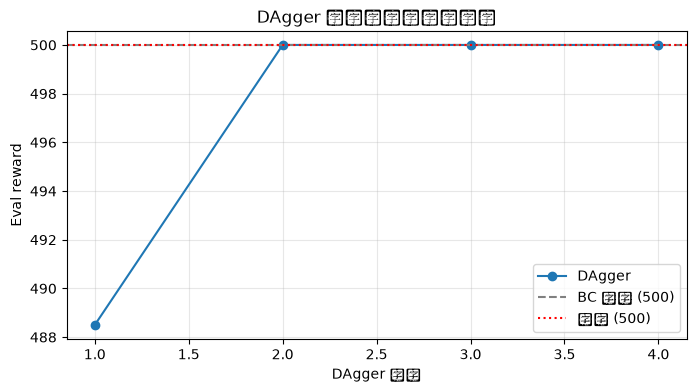

In [4]:
# 画 DAgger 轮数-回报曲线，与 BC 起点和专家对比
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, 5), rounds, "o-", label="DAgger")
ax.axhline(m_bc, color="gray", ls="--", label=f"BC 起点 ({m_bc:.0f})")
ax.axhline(m_exp, color="red", ls=":", label=f"专家 ({m_exp:.0f})")
ax.set_xlabel("DAgger 轮数")
ax.set_ylabel("Eval reward")
ax.set_title("DAgger 逐轮修复协变量偏移")
ax.legend()
ax.grid(alpha=0.3)
plt.show()


> 典型结果：2~3 轮之内回报就接近专家——学员只额外看了 4000 步环境交互，远少于从头训练一个 PPO。这就是「专家在场」的威力。

## 2. GAIL：不克隆动作，而是「猜奖励」

### 从 BC 到 GAIL 的视角转换

- BC 问：「专家在这个状态会做什么动作？」→ 直接模仿动作；
- GAIL（Ho & Ermon, 2016）问：「什么样的轨迹**看起来像**专家？」→ 学一个判别器来打分，把这个分数当奖励，用 RL 去最大化它。

### 数学形式

GAIL 是一个 minimax 博弈，和 GAN 几乎同构：

$$\min_\pi \max_D \; \mathbb{E}_{(s,a)\sim\pi}\big[\log(1 - D(s,a))\big] + \mathbb{E}_{(s,a)\sim\pi^*}\big[\log D(s,a)\big]$$

- **判别器** $D(s,a)$：输出「这个 (s,a) 来自专家」的概率，努力把专家与生成器分开；
- **生成器** $\pi$：一个普通 RL 策略（这里用 PPO），目标是让自己的 (s,a) 骗过判别器；
- 策略的奖励取 $r(s,a) = -\log(1 - D(s,a))$：判别器越觉得「像专家」，奖励越高。

### 与 DAgger 的对比直觉

DAgger 需要**专家在线标注**；GAIL 只需要**一批离线专家轨迹**，但要付出 RL 训练的交互代价。两者都在自己的分布上学习，都规避了 BC 的协变量偏移。

下面用 imitation 跑通：判别器 = `BasicRewardNet`（一个小 MLP），生成器 = PPO：


In [5]:
from imitation.algorithms.adversarial.gail import GAIL
from imitation.rewards.reward_nets import BasicRewardNet
from imitation.util.networks import RunningNorm

# GAIL 只需要离线专家轨迹（复用第 1 节采集的轨迹即可，多采一些效果更好）
expert_trajs = rollout.rollout(expert.policy, venv,
                               rollout.make_sample_until(None, min_episodes=8), rng=rng)

reward_net = BasicRewardNet(
    venv.observation_space, venv.action_space,
    normalize_input_layer=RunningNorm,  # 输入归一化：稳定判别器训练
)

gail_trainer = GAIL(
    demonstrations=expert_trajs,
    demo_batch_size=256,
    gen_replay_buffer_capacity=2048,
    n_disc_updates_per_round=4,       # 每轮判别器更新 4 次
    venv=venv,
    gen_algo=PPO("MlpPolicy", venv, seed=0, n_steps=256, batch_size=64, verbose=0),
    reward_net=reward_net,
    allow_variable_horizon=True,      # CartPole episode 长度可变，需显式允许
)

t0 = time.time()
gail_trainer.train(total_timesteps=10_000)  # CPU 约 5 秒
print(f"GAIL 训练 {time.time() - t0:.0f}s")

m_gail, s_gail = evaluate_policy(gail_trainer.policy, eval_env,
                                 n_eval_episodes=10, deterministic=True)
print(f"GAIL 回报: {m_gail:.1f} ± {s_gail:.1f}")


Running with `allow_variable_horizon` set to True. Some algorithms are biased towards shorter or longer episodes, which may significantly confound results. Additionally, even unbiased algorithms can exploit the information leak from the termination condition, producing spuriously high performance. See https://imitation.readthedocs.io/en/latest/getting-started/variable-horizon.html for more information.


round:   0%|          | 0/9 [00:00<?, ?it/s]

------------------------------------------
| raw/                        |          |
|    gen/rollout/ep_len_mean  | 22       |
|    gen/rollout/ep_rew_mean  | 22       |
|    gen/time/fps             | 9377     |
|    gen/time/iterations      | 1        |
|    gen/time/time_elapsed    | 0        |
|    gen/time/total_timesteps | 1024     |
------------------------------------------


--------------------------------------------------
| raw/                                |          |
|    disc/disc_acc                    | 0.543    |
|    disc/disc_acc_expert             | 0.777    |
|    disc/disc_acc_gen                | 0.309    |
|    disc/disc_entropy                | 0.691    |
|    disc/disc_loss                   | 0.686    |
|    disc/disc_proportion_expert_pred | 0.734    |
|    disc/disc_proportion_expert_true | 0.5      |
|    disc/global_step                 | 1        |
|    disc/n_expert                    | 256      |
|    disc/n_generated                 | 256      |
--------------------------------------------------


--------------------------------------------------
| raw/                                |          |
|    disc/disc_acc                    | 0.576    |
|    disc/disc_acc_expert             | 0.766    |
|    disc/disc_acc_gen                | 0.387    |
|    disc/disc_entropy                | 0.691    |
|    disc/disc_loss                   | 0.682    |
|    disc/disc_proportion_expert_pred | 0.689    |
|    disc/disc_proportion_expert_true | 0.5      |
|    disc/global_step                 | 1        |
|    disc/n_expert                    | 256      |
|    disc/n_generated                 | 256      |
--------------------------------------------------


...

-----------------------------------------------------
| mean/                               |             |
|    disc/disc_acc                    | 0.608       |
|    disc/disc_acc_expert             | 0.603       |
|    disc/disc_acc_gen                | 0.614       |
|    disc/disc_entropy                | 0.677       |
|    disc/disc_loss                   | 0.661       |
|    disc/disc_proportion_expert_pred | 0.494       |
|    disc/disc_proportion_expert_true | 0.5         |
|    disc/global_step                 | 9           |
|    disc/n_expert                    | 256         |
|    disc/n_generated                 | 256         |
|    gen/rollout/ep_len_mean          | 72.6        |
|    gen/rollout/ep_rew_mean          | 72.6        |
|    gen/rollout/ep_rew_wrapped_mean  | 42.7        |
|    gen/time/fps                     | 9.02e+03    |
|    gen/time/iterations              | 1           |
|    gen/time/time_elapsed            | 0           |
|    gen/time/total_timestep

round: 100%|██████████| 9/9 [00:02<00:00,  3.50it/s]

round: 100%|██████████| 9/9 [00:02<00:00,  3.26it/s]

GAIL 训练 3s


GAIL 回报: 446.0 ± 62.5


## 3. 检查 GAIL 学到的「奖励」

GAIL 的副产品是一个可查询的奖励函数。如果它学得有道理，那么**专家轨迹的 (s,a) 得分应该明显高于随机策略的 (s,a)**——这正是判别器被训练的初衷：


专家样本得分: 0.724 ± 0.112
随机样本得分: 0.594 ± 0.082


/data/wangf/robot_rl_learn/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 21028 (\N{CJK UNIFIED IDEOGRAPH-5224}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/data/wangf/robot_rl_learn/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 21035 (\N{CJK UNIFIED IDEOGRAPH-522B}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/data/wangf/robot_rl_learn/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 22120 (\N{CJK UNIFIED IDEOGRAPH-5668}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/data/wangf/robot_rl_learn/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 25226 (\N{CJK UNIFIED IDEOGRAPH-628A}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/data/wangf/robot_rl_learn/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py

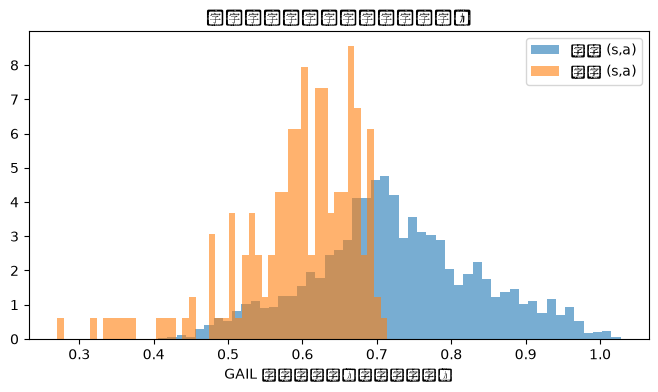

In [6]:
# 用判别器给专家样本 vs 随机样本打分
rand_trajs = rollout.rollout(None, venv,  # policy=None -> 随机动作
                             rollout.make_sample_until(None, min_episodes=8),
                             rng=np.random.default_rng(1))


def disc_score(trajs) -> np.ndarray:
    """用 GAIL 学到的奖励网络给一批轨迹的 (s,a) 打分。"""
    obs = np.concatenate([t.obs[:-1] for t in trajs]).astype(np.float32)
    acts = np.concatenate([t.acts for t in trajs])
    dones = np.zeros(len(obs))  # 演示打分，不涉及终止处理
    return gail_trainer.reward_train.predict_processed(obs, acts, obs, dones)


s_expert = disc_score(expert_trajs)
s_random = disc_score(rand_trajs)
print(f"专家样本得分: {s_expert.mean():.3f} ± {s_expert.std():.3f}")
print(f"随机样本得分: {s_random.mean():.3f} ± {s_random.std():.3f}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(s_expert, bins=50, alpha=0.6, density=True, label="专家 (s,a)")
ax.hist(s_random, bins=50, alpha=0.6, density=True, label="随机 (s,a)")
ax.set_xlabel("GAIL 判别器打分（学到的奖励）")
ax.set_title("判别器把专家与随机分开了吗？")
ax.legend()
plt.show()


> 注意：GAIL 学到的奖励**不等于环境的真实奖励**（CartPole 真实奖励是每步 +1）。它只是「像不像专家」的分数——理论上与真实奖励最多相差一个势函数塑形（potential-based shaping），这正是 AIRL 等后续工作研究的问题。

## 4. 三种方法对比

| 维度 | BC | DAgger | GAIL |
|------|-----|--------|------|
| 需要专家轨迹 | ✅ | ✅ | ✅ |
| 需要专家在线查询 | ❌ | ✅（每轮） | ❌ |
| 需要环境交互 | ❌ | ✅（少量） | ✅（RL 量级） |
| 训练稳定性 | 高（监督学习） | 高 | 低（minimax 博弈，像 GAN 一样会震荡） |
| 协变量偏移 | 有，$O(T^2\epsilon)$ | 消除，$O(T\epsilon)$ | 规避（在自己分布上优化） |
| 能超越专家 | ❌ | ❌（理论上） | 可能（RL 探索） |

工程选型建议：有离线数据先 BC 打基线；专家可查询用 DAgger 快速收敛；专家不可用但环境可交互、且愿意承受调参成本时用 GAIL。


## ✏️ 练习

### 练习 1（★，约 15 分钟）：DAgger 的 $\beta$ 混合系数
阅读 `SimpleDAggerTrainer` 文档中的 `beta_schedule` 参数：第 $i$ 轮采样时以概率 $\beta_i$ 执行**专家**动作、以 $1-\beta_i$ 执行学员动作。回答：为什么原始论文建议 $\beta_i$ 随轮数衰减，而实践中常直接设 $\beta_i = 0$（全程学员自己开）？
**可交付物**：3~5 句文字解释（提示：从「学员需要在自己访问的状态上学」和「初期学员太烂会瞬间坠机」两个角度）。

### 练习 2（★★，约 20 分钟）：DAgger 轮数消融
把第 1 节的 DAgger 训练改成 1 轮 × 4000 步（总交互量相同），与 4 轮 × 1000 步对比评估回报。
**可交付物**：两组数字 + 2~3 句解释：同样的交互总量，为什么分轮重训通常更好？

### 练习 3（★★，约 25 分钟）：GAIL 的专家数据量消融
固定 GAIL 其他设置，分别用 2 / 8 条专家轨迹训练 GAIL（各 10k 步），评估对比。
**可交付物**：对比表 + 一句话结论：GAIL 对专家数据量的敏感度与 BC 相比如何？

### 练习 4（★★★，约 30 分钟）：GAIL 奖励与真实奖励的相关性
在 CartPole 上收集若干条策略 rollout，对每一步同时记录：环境真实奖励（恒为 1，除了终止步）与 GAIL 判别器打分。画出散点并计算相关系数。
**可交付物**：散点图/相关系数 + 3~5 句讨论：既然真实奖励几乎恒定，判别器打分的方差来自哪里？它额外编码了什么信息？


## 参考答案

### 练习 1

<details>
<summary>参考答案</summary>

$\beta_i > 0$（混入专家动作）的作用是在训练初期保护数据采集：此时学员很烂，纯学员 rollout 会立刻坠机/摔杆，采到的全是「垃圾状态的垃圾后续」，专家标注意义有限；混入专家动作能让轨迹覆盖到「正常区域」。随着轮数增加、学员变强，$\beta_i$ 衰减到 0，让数据分布收敛到学员自己的分布——这正是消除协变量偏移的要求。实践中直接 $\beta=0$ 常见，因为：仿真里学员摔跤没有成本；且 beta 衰减调度本身又是一个要调的超参。
</details>

### 练习 2

<details>
<summary>参考答案</summary>

```python
# 1 轮 × 4000 步：只需把循环改成
dagger_trainer2 = dagger.SimpleDAggerTrainer(
    venv=venv, scratch_dir=make_run_dir("w10_dagger_1round"),
    expert_policy=expert.policy, rng=np.random.default_rng(0),
    bc_trainer=bc.BC(observation_space=venv.observation_space,
                     action_space=venv.action_space,
                     demonstrations=init_trajs, rng=np.random.default_rng(0)),
)
dagger_trainer2.train(total_timesteps=4_000)
m, _ = evaluate_policy(dagger_trainer2.policy, eval_env, n_eval_episodes=10)
print(m)
```

解释：1 轮 × 4000 步 = 只用 BC 策略采一次数据再重训一次；4 轮 = 「采一点 → 重训 → 用新策略再采」的闭环。分轮让后续数据来自越来越强的策略访问的分布，标注数据与最终部署分布更匹配；单次大批量采集的数据分布固定在初始（很差的）策略上。
</details>

### 练习 3

<details>
<summary>参考答案</summary>

```python
for n_ep in [2, 8]:
    trajs = expert_trajs[:n_ep]
    gail2 = GAIL(demonstrations=trajs, demo_batch_size=256,
                 gen_replay_buffer_capacity=2048, n_disc_updates_per_round=4,
                 venv=venv, allow_variable_horizon=True,
                 gen_algo=PPO("MlpPolicy", venv, seed=0, n_steps=256,
                              batch_size=64, verbose=0),
                 reward_net=BasicRewardNet(venv.observation_space,
                                           venv.action_space,
                                           normalize_input_layer=RunningNorm))
    gail2.train(total_timesteps=10_000)
    m, s = evaluate_policy(gail2.policy, eval_env, n_eval_episodes=10)
    print(f"{n_ep} 条轨迹: {m:.1f} ± {s:.1f}")
```

典型结论：GAIL 对数据量的敏感度低于 BC——2 条轨迹时判别器已能学到「立杆附近像专家」的粗粒度奖励，RL 探索会补齐剩余部分；但数据过少时判别器容易过拟合，奖励函数失真，训练不稳定。
</details>

### 练习 4

<details>
<summary>参考答案</summary>

```python
# 收集一条较长 rollout，逐步记录真实奖励与判别器打分
env = gym.make("CartPole-v1")
obs_list, act_list, true_r = [], [], []
obs, _ = env.reset(seed=7)
for _ in range(400):
    act, _ = gail_trainer.policy.predict(obs, deterministic=True)
    obs_list.append(obs)
    obs, r, term, trunc, _ = env.step(act)
    act_list.append(act)
    true_r.append(r)
    if term or trunc:
        break

scores = gail_trainer.reward_train.predict_processed(
    np.array(obs_list, dtype=np.float32), np.array(act_list),
    np.array(obs_list, dtype=np.float32), np.zeros(len(obs_list)))

import numpy as np
print("相关系数:", np.corrcoef(true_r, scores)[0, 1])
```

讨论：真实奖励几乎恒为 +1，因此「相关系数」本身意义有限（分母方差近零）；判别器打分的方差来自它对**状态-动作对质量**的评估——越接近「杆直立、小车居中」的专家状态，分越高；越接近倾倒边缘，分越低。也就是说判别器把「多步之后才会发生的失败」折算成了即时的奖励信号，这等价于学到了一个潜在的价值函数/势函数。
</details>


## 延伸阅读

- [Ross, Gordon & Bagnall, DAgger (AISTATS 2011)](https://arxiv.org/abs/1011.0686) —— 本周主读论文
- [Ho & Ermon, GAIL: Generative Adversarial Imitation Learning (NeurIPS 2016)](https://arxiv.org/abs/1606.03476) —— GAIL 原始论文
- [imitation 官方文档：DAgger 与 GAIL 教程](https://imitation.readthedocs.io/) —— 本周全部代码的 API 出处
- [Fu, Luo & Levine, AIRL: Learning Robust Rewards with Adversarial IRL (ICLR 2018)](https://arxiv.org/abs/1710.11248) —— GAIL 奖励「只相差一个势函数」问题的后续工作
- [Goodfellow et al., Generative Adversarial Networks (NeurIPS 2014)](https://arxiv.org/abs/1406.2661) —— 理解 GAIL 的 GAN 源头
